# Chapter 2: The Measurement Equation and Bayesian Framework

The Bayesian posterior for atmospheric retrieval:

$$P(\mathbf{x} | \mathbf{y}) \propto \underbrace{\exp\!\left(-\frac{1}{2}[\mathbf{y}-F(\mathbf{x})]^T S_\varepsilon^{-1}[\mathbf{y}-F(\mathbf{x})]\right)}_{\text{likelihood}} \cdot \underbrace{\exp\!\left(-\frac{1}{2}(\mathbf{x}-\mathbf{x}_a)^T S_a^{-1}(\mathbf{x}-\mathbf{x}_a)\right)}_{\text{prior}}$$

In this notebook we build the full cost function, visualise the trade-off between
data fit and prior constraint, and compute the Degrees of Freedom for Signal.


In [1]:
import pandas as pd
import plotly.express as px

# Data (using realistic operational assumptions)
data = [
    ["SCIAMACHY", "2002-01-01", "2012-04-08"],
    ["GOSAT", "2009-01-23", "2026-12-31"],
    ["OCO-2", "2014-07-02", "2026-12-31"],
    ["TanSat", "2016-12-22", "2026-12-31"],
    ["GOSAT-2", "2018-10-29", "2026-12-31"],
    ["OCO-3", "2019-05-04", "2026-12-31"],
    ["MicroCarb (planned)", "2025-01-01", "2028-12-31"],
    ["GeoCarb (planned)", "2025-01-01", "2028-12-31"],
    ["CO2M / Sentinel-7 (planned)", "2027-01-01", "2032-12-31"],
]

df = pd.DataFrame(data, columns=["Mission", "Start", "End"])

# Convert to datetime (THIS fixes blank plot)
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])

# Create timeline
fig = px.timeline(
    df,
    x_start="Start",
    x_end="End",
    y="Mission",
    color="Mission"
)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    title="CO₂ Monitoring Satellite Timeline",
    xaxis_title="Year",
    yaxis_title="",
    showlegend=False
)

# Save as PNG (requires: pip install kaleido)
fig.write_image("co2_satellite_timeline.png", width=1200, height=600)

fig.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

In [2]:
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
np.random.seed(42)

# ── Physical constants for Planck function ─────────────────────
h  = 6.626e-34; c_cgs = 3e10; kB = 1.38e-23
c2 = h * c_cgs / kB

def planck(nu, T):
    c1 = 2 * h * c_cgs**2
    return c1 * nu**3 / (np.expm1(c2 * nu / T))

def rad_to_BT(nu, B):
    c1 = 2 * h * c_cgs**2
    return c2 * nu / np.log(1 + c1 * nu**3 / B)

print("Ready.")


Ready.


## 2.1 The Cost Function — Misfit vs Prior Constraint

The OE cost function has two competing terms:

$$
J(\mathbf{x}) =
\underbrace{(\mathbf{y} - F(\mathbf{x}))^{T} \mathbf{S}_{\epsilon}^{-1} (\mathbf{y} - F(\mathbf{x}))}_{\text{data misfit}}
+
\underbrace{(\mathbf{x} - \mathbf{x}_a)^{T} \mathbf{S}_a^{-1} (\mathbf{x} - \mathbf{x}_a)}_{\text{prior constraint}}
$$        

The minimum of J(x) = the MAP estimate = the OE solution.

Let's visualise this for a 2D state space (two temperature levels).


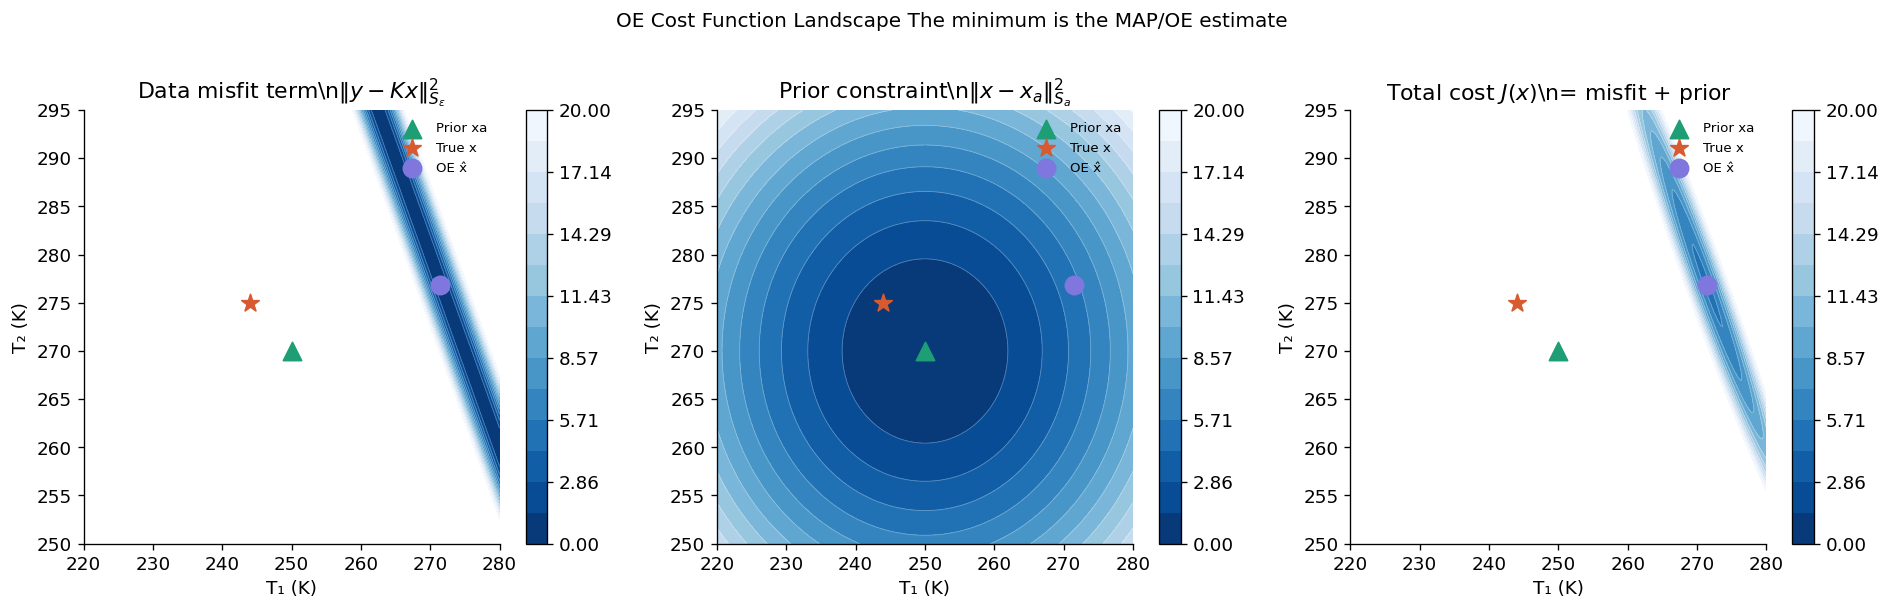

Prior xa       = [250. 270.]
True x_true    = [244. 275.]
OE solution x̂  = [271.42 276.86]
Posterior cov diagonal: [3.78 7.43] K


In [5]:
# 2D visualisation of the OE cost function
# State: x = [T1, T2] (two atmospheric levels)
# Prior: xa = [250, 270] K, sigma_a = [10, 8] K (uncorrelated)
# Measurement: y = [240 K BT], one channel, linearised

xa = np.array([250.0, 270.0])
Sa = np.diag([10.0**2, 8.0**2])
Se = np.array([[0.5**2]])    # BT noise 0.5 K

# Simplified linearised Jacobian: channel sensitive to level 1 (K1=0.6) and level 2 (K2=0.3)
K = np.array([[0.6, 0.3]])
y_obs = np.array([246.0])    # measured BT (K)

# True state
x_true = np.array([244.0, 275.0])

T1_grid = np.linspace(220, 280, 200)
T2_grid = np.linspace(250, 295, 200)
T1, T2 = np.meshgrid(T1_grid, T2_grid)

# Cost function on grid
J_data  = np.zeros_like(T1)
J_prior = np.zeros_like(T1)
Sa_inv  = np.linalg.inv(Sa)
Se_inv  = np.linalg.inv(Se)

for i in range(200):
    for j in range(200):
        x_vec  = np.array([T1[i,j], T2[i,j]])
        Fx     = K @ x_vec
        r_data = y_obs - Fx
        r_prior= x_vec - xa
        J_data[i,j]  = float(r_data.T @ Se_inv @ r_data)
        J_prior[i,j] = float(r_prior.T @ Sa_inv @ r_prior)

J_total = J_data + J_prior

# Analytical OE solution
Sa_inv_dense = np.linalg.inv(Sa)
Se_inv_dense = np.linalg.inv(Se)
posterior_cov = np.linalg.inv(K.T @ Se_inv_dense @ K + Sa_inv_dense)
gain = posterior_cov @ K.T @ Se_inv_dense
x_hat = xa + gain @ (y_obs - K @ xa)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
levels = np.linspace(0, 20, 15)

for ax, (J, title) in zip(axes, [
    (J_data,  r"Data misfit term\n$\|y - Kx\|^2_{S_\epsilon}$"),
    (J_prior, r"Prior constraint\n$\|x - x_a\|^2_{S_a}$"),
    (J_total, r"Total cost $J(x)$\n= misfit + prior"),
]):
    cf = ax.contourf(T1_grid, T2_grid, J, levels=levels, cmap="Blues_r")
    ax.contour(T1_grid, T2_grid, J, levels=levels, colors="white", alpha=0.3, linewidths=0.5)
    plt.colorbar(cf, ax=ax)
    ax.scatter(*xa, s=120, color="#1D9E75", marker="^", zorder=5, label="Prior xa")
    ax.scatter(*x_true, s=120, color="#D85A30", marker="*", zorder=5, label="True x")
    ax.scatter(*x_hat, s=120, color="#7F77DD", marker="o", zorder=5, label="OE x̂")
    ax.set_xlabel("T₁ (K)"); ax.set_ylabel("T₂ (K)")
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)

plt.suptitle("OE Cost Function Landscape The minimum is the MAP/OE estimate",  fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"Prior xa       = {xa}")
print(f"True x_true    = {x_true}")
print(f"OE solution x̂  = {np.round(x_hat, 2)}")
print(f"Posterior cov diagonal: {np.round(np.sqrt(np.diag(posterior_cov)), 2)} K")


## 2.2 Averaging Kernels — What the Retrieval Actually Measures

The averaging kernel matrix A = G·K tells us how the retrieved state relates
to the true state:

    x̂ - xa = A(x_true - xa) + noise term

Diagonal element A_ii: sensitivity of retrieval at level i to truth at level i.
Off-diagonal A_ij: retrieval at level i contaminated by truth at level j (vertical smearing).


/tmp/ipykernel_16401/1434911483.py:68: RuntimeWarning: invalid value encountered in sqrt
  sigma_post  = np.sqrt(np.diag(S_post))


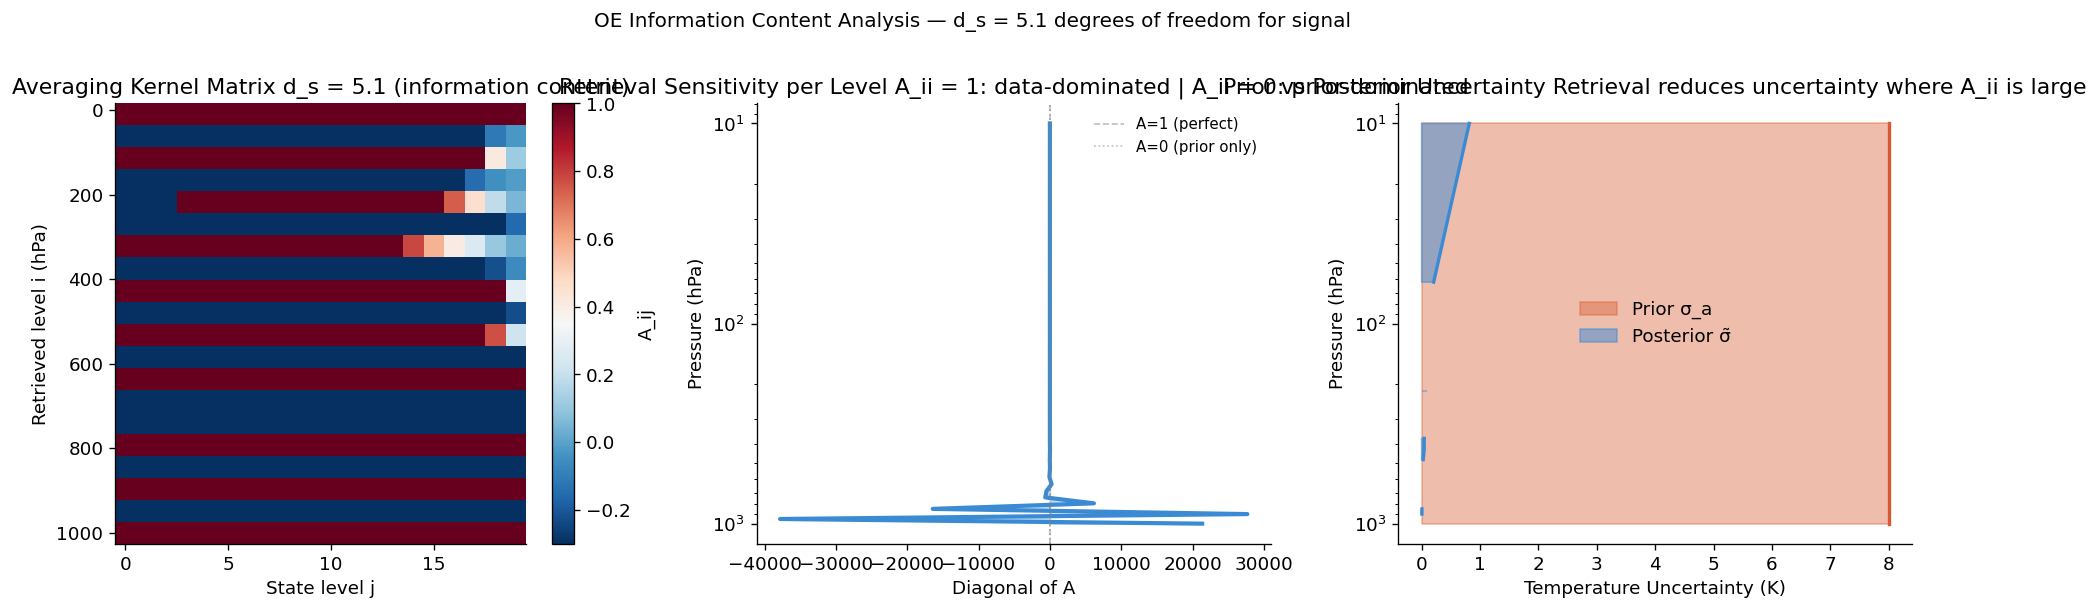

Degrees of freedom for signal: d_s = 5.14
(Out of 20 state levels)
Max information comes from levels: [ 895 1000  791] hPa


In [8]:
# Build a realistic multi-level OE system
# 20-level temperature sounding with IASI-like setup
n_levels = 20
p_levels = np.linspace(1000, 10, n_levels)
z_km = 16 * np.log(1013 / p_levels)

# Generate weighting functions for n_ch channels
n_ch = 12
nu_channels = np.linspace(660, 750, n_ch)

# Build K matrix: each channel has weighting function peaking at different level
K_matrix = np.zeros((n_ch, n_levels))
for i, nu in enumerate(nu_channels):
    # Optical depth increases with absorption: higher nu closer to 667 = more absorbing
    tau_strength = 5 * np.exp(-(nu - 667)**2 / 400)  # peaks at CO2 core
    k_prof = tau_strength * p_levels / 1013.0
    dp = np.gradient(p_levels)
    tau_cum = np.cumsum(k_prof * np.abs(dp) / 1013.0)[::-1][::-1]
    t_p = np.exp(-tau_cum)
    dBdT_p = 1.0  # simplified
    K_matrix[i, :] = -np.gradient(t_p, p_levels) * dBdT_p

K_matrix /= K_matrix.max()   # normalise for visualisation

# A priori covariance: correlated profile (nearby levels correlated)
corr_length = 3  # levels
Sa_matrix = np.zeros((n_levels, n_levels))
for i in range(n_levels):
    for j in range(n_levels):
        Sa_matrix[i,j] = 8.0**2 * np.exp(-abs(i-j)/corr_length)

Se_matrix = 0.3**2 * np.eye(n_ch)   # 0.3 K BT noise

# OE solution matrices
Sa_inv = np.linalg.inv(Sa_matrix)
Se_inv = np.linalg.inv(Se_matrix)
S_post = np.linalg.inv(K_matrix.T @ Se_inv @ K_matrix + Sa_inv)
G_gain = S_post @ K_matrix.T @ Se_inv
A_kern = G_gain @ K_matrix

# Degrees of freedom for signal
d_s = np.trace(A_kern)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Averaging kernel matrix
im = axes[0].pcolormesh(np.arange(n_levels), p_levels, A_kern,
                        cmap="RdBu_r", vmin=-0.3, vmax=1.0)
plt.colorbar(im, ax=axes[0], label="A_ij")
axes[0].invert_yaxis()
axes[0].set_xlabel("State level j"); axes[0].set_ylabel("Retrieved level i (hPa)")
axes[0].set_title(f"Averaging Kernel Matrix d_s = {d_s:.1f} (information content)")

# Diagonal of A (sensitivity per level)
axes[1].plot(np.diag(A_kern), p_levels, "#3B8BD4", lw=2.5)
axes[1].axvline(1.0, color="gray", lw=1, ls="--", alpha=0.5, label="A=1 (perfect)")
axes[1].axvline(0.0, color="gray", lw=1, ls=":", alpha=0.5, label="A=0 (prior only)")
axes[1].fill_betweenx(p_levels, 0, np.diag(A_kern), alpha=0.3, color="#3B8BD4")
axes[1].invert_yaxis()
axes[1].set_yscale("log")
axes[1].set_xlabel("Diagonal of A")
axes[1].set_ylabel("Pressure (hPa)")
axes[1].set_title("Retrieval Sensitivity per Level A_ii = 1: data-dominated | A_ii = 0: prior-dominated")
axes[1].legend(frameon=False, fontsize=9)

# Prior vs posterior uncertainty
sigma_prior = np.sqrt(np.diag(Sa_matrix))
sigma_post  = np.sqrt(np.diag(S_post))
axes[2].fill_betweenx(p_levels, 0, sigma_prior, alpha=0.4, color="#D85A30", label="Prior σ_a")
axes[2].fill_betweenx(p_levels, 0, sigma_post,  alpha=0.5, color="#3B8BD4", label="Posterior σ̃")
axes[2].plot(sigma_prior, p_levels, "#D85A30", lw=2)
axes[2].plot(sigma_post,  p_levels, "#3B8BD4",  lw=2)
axes[2].invert_yaxis()
axes[2].set_yscale("log")
axes[2].set_xlabel("Temperature Uncertainty (K)")
axes[2].set_ylabel("Pressure (hPa)")
axes[2].set_title("Prior vs Posterior Uncertainty Retrieval reduces uncertainty where A_ii is large")
axes[2].legend(frameon=False)

plt.suptitle(f"OE Information Content Analysis — d_s = {d_s:.1f} degrees of freedom for signal",fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"Degrees of freedom for signal: d_s = {d_s:.2f}")
print(f"(Out of {n_levels} state levels)")
print(f"Max information comes from levels: {p_levels[np.argsort(np.diag(A_kern))[::-1][:3]].astype(int)} hPa")


In [9]:
print("Chapter 2 complete!")
print()
print("Key matrices in OE:")
print("  K     : Jacobian (m × n) - sensitivity of measurements to state")
print("  Sa    : A priori covariance (n × n) - prior uncertainty + correlations")
print("  Sε    : Measurement error covariance (m × m) - instrument noise")
print("  G     : Gain matrix G = (KᵀSε⁻¹K + Sa⁻¹)⁻¹ KᵀSε⁻¹")
print("  A     : Averaging kernel A = GK  (how well we actually retrieve each level)")
print("  S̃     : Posterior covariance S̃ = (KᵀSε⁻¹K + Sa⁻¹)⁻¹")
print("  d_s   : Degrees of freedom for signal = trace(A)")


Chapter 2 complete!

Key matrices in OE:
  K     : Jacobian (m × n) - sensitivity of measurements to state
  Sa    : A priori covariance (n × n) - prior uncertainty + correlations
  Sε    : Measurement error covariance (m × m) - instrument noise
  G     : Gain matrix G = (KᵀSε⁻¹K + Sa⁻¹)⁻¹ KᵀSε⁻¹
  A     : Averaging kernel A = GK  (how well we actually retrieve each level)
  S̃     : Posterior covariance S̃ = (KᵀSε⁻¹K + Sa⁻¹)⁻¹
  d_s   : Degrees of freedom for signal = trace(A)
